In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score, roc_curve, roc_auc_score, accuracy_score
import torch
import torch.nn as nn
import torchvision.models as tv_models
from utils import FiSHNN, make_loader, make_single_loader

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configuration
BS = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] using device: {device}")
if device.type == 'cuda':
    print(f"[INFO] GPU Name: {torch.cuda.get_device_name(0)}")

# Load saved data and metadata
data = np.load('models/data.npy')
test_idx = np.load('models/test_idx.npy')

# Recreate label encoders
species_le = LabelEncoder()
habitat_le = LabelEncoder()
# Load and rename 'Scheldt' to 'SE'
species_le.classes_ = np.array([c if c != 'Scheldt' else 'SE' for c in np.load('models/species_le.npy')])
habitat_le.classes_ = np.array([c if c != 'Scheldt' else 'SE' for c in np.load('models/habitat_le.npy')])

num_species = len(species_le.classes_)
num_habitats = len(habitat_le.classes_)

# Load test set labels
test_labels_dict = np.load('models/test_labels.npy', allow_pickle=True).item()
test_species_y = test_labels_dict['species']
test_habitat_y = test_labels_dict['habitat']
test_data = data[test_idx]

# Generate all possible species-habitat combinations
all_labels = [f"{s}-{h}" for s in species_le.classes_ for h in habitat_le.classes_]

print(f"[INFO] Data shape: {data.shape}")
print(f"[INFO] Test set size: {len(test_idx)} ({len(test_idx)/len(data)*100:.1f}%)")
print(f"[INFO] Species classes: {species_le.classes_}")
print(f"[INFO] Habitat classes: {habitat_le.classes_}")

print(f"\n[INFO] Test set species distribution:")
for i, cls in enumerate(species_le.classes_):
    count = (test_species_y == i).sum()
    print(f"  {cls}: {count}")
    
print(f"\n[INFO] Test set habitat distribution:")
for i, cls in enumerate(habitat_le.classes_):
    count = (test_habitat_y == i).sum()
    print(f"  {cls}: {count}")

[INFO] using device: cuda
[INFO] GPU Name: NVIDIA GeForce RTX 4090
[INFO] Data shape: (1389, 256, 256, 3)
[INFO] Test set size: 278 (20.0%)
[INFO] Species classes: ['AF' 'AM' 'AT' 'CH' 'HL' 'SS']
[INFO] Habitat classes: ['BCS' 'DCS' 'SE']

[INFO] Test set species distribution:
  AF: 4
  AM: 26
  AT: 47
  CH: 109
  HL: 9
  SS: 83

[INFO] Test set habitat distribution:
  BCS: 200
  DCS: 70
  SE: 8


## Load Trained Models

In [3]:
# Load FiSHNN best model
fishnn_model = FiSHNN(num_species=num_species, num_habitats=num_habitats).to(device)
fishnn_state = torch.load('models/FiSHNN_best.pt', map_location=device)
fishnn_model.load_state_dict(fishnn_state)
fishnn_model.eval()

# Load Species single-task model
species_model = tv_models.efficientnet_b0(weights="DEFAULT")  # Transfer Learning
species_model.classifier = nn.Sequential(nn.Dropout(p=0.2, inplace=True), nn.Linear(1280, num_species))
species_model = species_model.to(device)
species_state = torch.load('models/EfficientNet_Species_best.pt', map_location=device)
species_model.load_state_dict(species_state)
species_model.eval()

# Load Habitat single-task model
habitat_model = tv_models.efficientnet_b0(weights="DEFAULT") # Transfer Learning
habitat_model.classifier = nn.Sequential(nn.Dropout(p=0.2, inplace=True), nn.Linear(1280, num_habitats))
habitat_model = habitat_model.to(device)
habitat_state = torch.load('models/EfficientNet_Habitat_best.pt', map_location=device)
habitat_model.load_state_dict(habitat_state)
habitat_model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

## Evaluate on Test Set

In [4]:
# --- Evaluate FiSHNN & Single-task Models on Test Set ---
dummy_species_y = np.arange(len(data)) % num_species
dummy_habitat_y = np.arange(len(data)) % num_habitats
test_loader = make_loader(data, dummy_species_y, dummy_habitat_y, test_idx, BS, shuffle=False)

fishnn_species_logits = []
fishnn_habitat_logits = []

with torch.no_grad():
    for xb, _, _ in test_loader:
        xb = xb.to(device)
        s_logit, h_logit = fishnn_model(xb)
        fishnn_species_logits.append(s_logit.cpu())
        fishnn_habitat_logits.append(h_logit.cpu())

fishnn_species_logits = torch.cat(fishnn_species_logits)
fishnn_habitat_logits = torch.cat(fishnn_habitat_logits)
fishnn_species_probs = torch.softmax(fishnn_species_logits, dim=1).numpy()
fishnn_habitat_probs = torch.softmax(fishnn_habitat_logits, dim=1).numpy()
fishnn_species_preds = fishnn_species_probs.argmax(axis=1)
fishnn_habitat_preds = fishnn_habitat_probs.argmax(axis=1)

# Evaluate single-task models
full_species_y = np.zeros(len(data), dtype=int)
full_species_y[test_idx] = test_species_y
full_habitat_y = np.zeros(len(data), dtype=int)
full_habitat_y[test_idx] = test_habitat_y

species_test_loader = make_single_loader(data, test_idx, full_species_y, BS, shuffle=False)
species_logits = []
with torch.no_grad():
    for xb, _ in species_test_loader:
        xb = xb.to(device)
        logit = species_model(xb)
        species_logits.append(logit.cpu())
species_probs = torch.softmax(torch.cat(species_logits), dim=1).numpy()
species_preds = species_probs.argmax(axis=1)

habitat_test_loader = make_single_loader(data, test_idx, full_habitat_y, BS, shuffle=False)
habitat_logits = []
with torch.no_grad():
    for xb, _ in habitat_test_loader:
        xb = xb.to(device)
        logit = habitat_model(xb)
        habitat_logits.append(logit.cpu())
habitat_probs = torch.softmax(torch.cat(habitat_logits), dim=1).numpy()
habitat_preds = habitat_probs.argmax(axis=1)

# --- Calculate Metrics immediately so they are available for all subsequent cells ---
species_targets_onehot = np.eye(num_species)[test_species_y]
habitat_targets_onehot = np.eye(num_habitats)[test_habitat_y]

# FiSHNN Metrics
fishnn_acc_species = accuracy_score(test_species_y, fishnn_species_preds)
fishnn_acc_habitat = accuracy_score(test_habitat_y, fishnn_habitat_preds)
fishnn_ap_species = average_precision_score(species_targets_onehot, fishnn_species_probs)
fishnn_ap_habitat = average_precision_score(habitat_targets_onehot, fishnn_habitat_probs)
fishnn_auc_species = roc_auc_score(species_targets_onehot, fishnn_species_probs)
fishnn_auc_habitat = roc_auc_score(habitat_targets_onehot, fishnn_habitat_probs)

# Single-task Metrics
single_acc_species = accuracy_score(test_species_y, species_preds)
single_acc_habitat = accuracy_score(test_habitat_y, habitat_preds)
single_ap_species = average_precision_score(species_targets_onehot, species_probs)
single_ap_habitat = average_precision_score(habitat_targets_onehot, habitat_probs)
single_auc_species = roc_auc_score(species_targets_onehot, species_probs)
single_auc_habitat = roc_auc_score(habitat_targets_onehot, habitat_probs)

## Model Performance and Efficiency Comparison
This section evaluates the trained models on the independent test set (20% split) and compares their classification metrics and inference speed.

[INFO] Measuring inference latency...


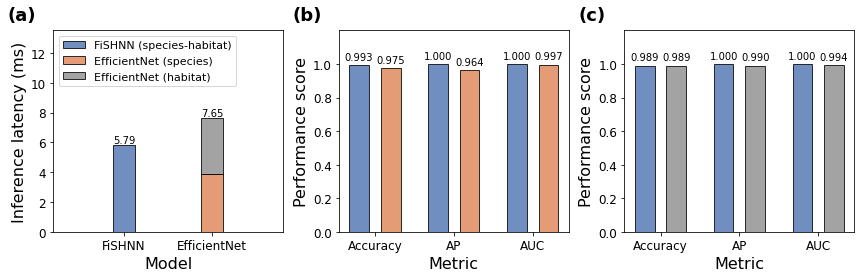

In [5]:
# --- Figure 1: Model Performance and Efficiency Comparison ---

# Performance Data
metrics = ['Accuracy', 'AP', 'AUC']
mtl_spe = [fishnn_acc_species, fishnn_ap_species, fishnn_auc_species]
stl_spe = [single_acc_species, single_ap_species, single_auc_species]
mtl_hab = [fishnn_acc_habitat, fishnn_ap_habitat, fishnn_auc_habitat]
stl_hab = [single_acc_habitat, single_ap_habitat, single_auc_habitat]

# Latency Measurement (6 Shared Layers)
print("[INFO] Measuring inference latency...")
with torch.no_grad():
    num_benchmark = 100
    test_images_tensor = torch.randn(num_benchmark, 3, 224, 224).to(device)

    def get_latency(model_obj, inputs):
        for _ in range(10): _ = model_obj(inputs[:1]) # Warmup
        if torch.cuda.is_available():
            start_event = torch.cuda.Event(enable_timing=True)
            end_event = torch.cuda.Event(enable_timing=True)
            start_event.record()
            for i in range(num_benchmark): _ = model_obj(inputs[i:i+1])
            end_event.record()
            torch.cuda.synchronize()
            return start_event.elapsed_time(end_event) / num_benchmark
        else:
            import time
            start = time.time()
            for i in range(num_benchmark): _ = model_obj(inputs[i:i+1])
            return ((time.time() - start) * 1000) / num_benchmark

    mtl_ms = get_latency(fishnn_model, test_images_tensor)
    spe_lat = get_latency(species_model, test_images_tensor)
    hab_lat = get_latency(habitat_model, test_images_tensor)
    stl_ms = spe_lat + hab_lat

# Plotting Figure 1 (1x3 Layout)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
x = np.arange(len(metrics))

# Configuration
width = 0.25
spacing = 0.4 
offset = spacing / 2.0 
colors = {'mtl': '#4C72B0', 'spe': '#DD8452', 'hab': '#8C8C8C'}
fs_label = 16
fs_ticks = 12
fs_legend = 11
fs_text = 10
label_font = {'size': 18, 'weight': 'bold'}

# Performance Shared Settings (b and c)
ticks_perf = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
limit_perf = 1.2

# (a) Inference Latency
x_latency = np.arange(2)
ax[0].bar(0, mtl_ms, width, color=colors['mtl'], alpha=0.8, edgecolor='black', label='FiSHNN (species-habitat)')
ax[0].bar(1, spe_lat, width, color=colors['spe'], alpha=0.8, edgecolor='black', label='EfficientNet (species)')
ax[0].bar(1, hab_lat, width, bottom=spe_lat, color=colors['hab'], alpha=0.8, edgecolor='black', label='EfficientNet (habitat)')
ax[0].set_xticks(x_latency)
ax[0].set_xticklabels(['FiSHNN', 'EfficientNet'], fontsize=fs_ticks)
ax[0].set_xlabel('Model', fontsize=fs_label)
ax[0].set_ylim(0, 13.5) 
ax[0].set_ylabel('Inference latency (ms)', fontsize=fs_label)
ax[0].set_xlim([-0.8, 1.8])
ax[0].grid(False) 
ax[0].legend(loc='upper left', frameon=True, fontsize=fs_legend)
ax[0].text(0, mtl_ms, f'{mtl_ms:.2f}', ha='center', va='bottom', fontsize=fs_text)
ax[0].text(1, stl_ms, f'{stl_ms:.2f}', ha='center', va='bottom', fontsize=fs_text)
ax[0].text(-0.2, 1.12, '(a)', transform=ax[0].transAxes, ha='left', va='top', **label_font)
ax[0].margins(y=0.3) # Automatically adjust Y-axis to fit labels and legend

# (b) Species Performance
ax[1].bar(x - offset, mtl_spe, width, label='FiSHNN', color=colors['mtl'], alpha=0.8, edgecolor='black')
ax[1].bar(x + offset, stl_spe, width, label='EfficientNet', color=colors['spe'], alpha=0.8, edgecolor='black')
ax[1].set_xticks(x)
ax[1].set_xticklabels(metrics, fontsize=fs_ticks)
ax[1].set_xlabel('Metric', fontsize=fs_label)
ax[1].set_ylabel('Performance score', fontsize=fs_label)
ax[1].set_yticks(ticks_perf)
ax[1].set_ylim(0, limit_perf)
ax[1].grid(False)
for i, v in enumerate(mtl_spe): ax[1].text(i - offset, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=fs_text)
for i, v in enumerate(stl_spe): ax[1].text(i + offset, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=fs_text)
ax[1].text(-0.2, 1.12, '(b)', transform=ax[1].transAxes, ha='left', va='top', **label_font)

# (c) Habitat Performance
ax[2].bar(x - offset, mtl_hab, width, label='FiSHNN', color=colors['mtl'], alpha=0.8, edgecolor='black')
ax[2].bar(x + offset, stl_hab, width, label='EfficientNet', color=colors['hab'], alpha=0.8, edgecolor='black')
ax[2].set_xticks(x)
ax[2].set_xticklabels(metrics, fontsize=fs_ticks)
ax[2].set_xlabel('Metric', fontsize=fs_label)
ax[2].set_ylabel('Performance score', fontsize=fs_label)
ax[2].set_yticks(ticks_perf)
ax[2].set_ylim(0, limit_perf)
ax[2].grid(False)
for i, v in enumerate(mtl_hab): ax[2].text(i - offset, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=fs_text)
for i, v in enumerate(stl_hab): ax[2].text(i + offset, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=fs_text)
ax[2].text(-0.2, 1.12, '(c)', transform=ax[2].transAxes, ha='left', va='top', **label_font)

for i in range(3): ax[i].tick_params(axis='both', labelsize=fs_ticks)

plt.tight_layout()
plt.savefig('./Figs/Figure_3_model_comparison.pdf')
plt.savefig('./Figs/Figure_3_model_comparison.png', dpi=600, bbox_inches='tight')

In [6]:
# --- Print Summary Table and Save to CSV ---
print("\n" + "="*80)
print("TEST SET PERFORMANCE COMPARISON")
print("="*80)
comparison_df = pd.DataFrame({
    'Model': ['FiSHNN', 'EfficientNet', 'FiSHNN', 'EfficientNet'],
    'Task': ['Species', 'Species', 'Habitat', 'Habitat'],
    'Accuracy (%)': [f'{fishnn_acc_species*100:.2f}', f'{single_acc_species*100:.2f}', 
                     f'{fishnn_acc_habitat*100:.2f}', f'{single_acc_habitat*100:.2f}'],
    'AP': [f'{fishnn_ap_species:.3f}', f'{single_ap_species:.3f}', 
           f'{fishnn_ap_habitat:.3f}', f'{single_ap_habitat:.3f}'],
    'AUC': [f'{fishnn_auc_species:.3f}', f'{single_auc_species:.3f}', 
            f'{fishnn_auc_habitat:.3f}', f'{single_auc_habitat:.3f}']
})
print(comparison_df.to_string(index=False))
print("="*80)

# Save results for external use
comparison_df.to_csv('models/test_performance_comparison.csv', index=False)


TEST SET PERFORMANCE COMPARISON
       Model    Task Accuracy (%)    AP   AUC
      FiSHNN Species        99.28 1.000 1.000
EfficientNet Species        97.48 0.964 0.997
      FiSHNN Habitat        98.92 1.000 1.000
EfficientNet Habitat        98.92 0.990 0.994


## Confusion Matrices

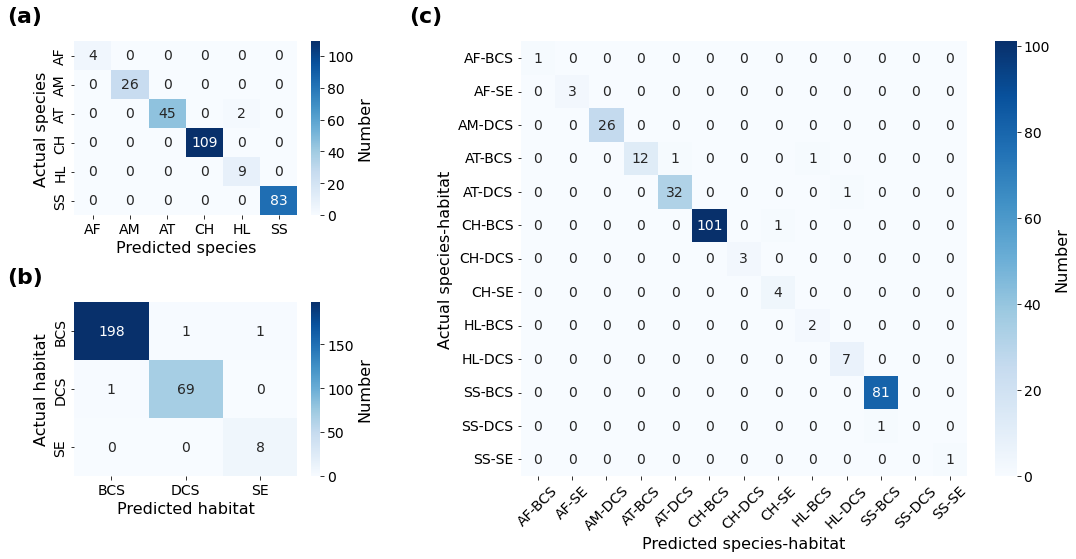

In [7]:
# Generate confusion matrices for FiSHNN predictions on test set
cm_species = confusion_matrix(test_species_y, fishnn_species_preds)
cm_habitat = confusion_matrix(test_habitat_y, fishnn_habitat_preds)

cm_species_df = pd.DataFrame(cm_species, index=species_le.classes_, columns=species_le.classes_)
cm_habitat_df = pd.DataFrame(cm_habitat, index=habitat_le.classes_, columns=habitat_le.classes_)

# Create combined species-habitat labels for FiSHNN predictions
trueCombinedY = [f'{species_le.classes_[s]}-{habitat_le.classes_[h]}' for s, h in zip(test_species_y, test_habitat_y)]
predCombinedY = [f'{species_le.classes_[s]}-{habitat_le.classes_[h]}' for s, h in zip(fishnn_species_preds, fishnn_habitat_preds)]
allCombinedLabels = [f'{s}-{h}' for s in species_le.classes_ for h in habitat_le.classes_]
cm_combined = confusion_matrix(trueCombinedY, predCombinedY, labels=allCombinedLabels)

# Filter non-zero labels for joint CM
non_zero_indices = [i for i, label in enumerate(allCombinedLabels) if cm_combined[i, :].sum() > 0 or cm_combined[:, i].sum() > 0]
non_zero_labels = [allCombinedLabels[i] for i in non_zero_indices]
cm_combined_filtered = cm_combined[np.ix_(non_zero_indices, non_zero_indices)]
cm_combined_df = pd.DataFrame(cm_combined_filtered, index=non_zero_labels, columns=non_zero_labels)

# Plot Combined Confusion Matrices (Figure 2 & 3)
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 2], hspace=0.5, wspace=0.4)

ax_spec = fig.add_subplot(gs[0, 0])
ax_hab = fig.add_subplot(gs[1, 0])
ax_joint = fig.add_subplot(gs[:, 1])

# Visual settings
annot_kws = {'size': 14}
xlabel_size = 16
ylabel_size = 16
tick_label_size = 14
colorbar_size = 16
colorbar_tick_size = 14

# Subplot labels settings
label_font = {'size': 22, 'weight': 'bold'}

# 1. Species CM
sns.heatmap(cm_species_df, ax=ax_spec, annot=True, fmt='g', cmap='Blues', cbar=True, annot_kws=annot_kws)
ax_spec.set_ylabel('Actual species', fontsize=ylabel_size)
ax_spec.set_xlabel('Predicted species', fontsize=xlabel_size)
ax_spec.tick_params(axis='both', labelsize=tick_label_size)
cb_spec = ax_spec.collections[0].colorbar
cb_spec.ax.tick_params(labelsize=colorbar_tick_size)
cb_spec.set_label('Number', fontsize=colorbar_size)
ax_spec.text(-0.3, 1.2, '(a)', transform=ax_spec.transAxes, ha='left', va='top', **label_font)

# 2. Habitat CM
sns.heatmap(cm_habitat_df, ax=ax_hab, annot=True, fmt='g', cmap='Blues', cbar=True, annot_kws=annot_kws)
ax_hab.set_ylabel('Actual habitat', fontsize=ylabel_size)
ax_hab.set_xlabel('Predicted habitat', fontsize=xlabel_size)
ax_hab.tick_params(axis='both', labelsize=tick_label_size)
cb_hab = ax_hab.collections[0].colorbar
cb_hab.ax.tick_params(labelsize=colorbar_tick_size)
cb_hab.set_label('Number', fontsize=colorbar_size)
ax_hab.text(-0.3, 1.2, '(b)', transform=ax_hab.transAxes, ha='left', va='top', **label_font)

# 3. Joint CM (Occupies entire second column)
sns.heatmap(cm_combined_df, ax=ax_joint, annot=True, fmt='g', cmap='Blues', cbar=True, annot_kws=annot_kws)
ax_joint.set_ylabel('Actual species-habitat', fontsize=ylabel_size)
ax_joint.set_xlabel('Predicted species-habitat', fontsize=xlabel_size)
# Force horizontal rotation for y-axis labels to prevent overlap
ax_joint.tick_params(axis='y', labelsize=tick_label_size, rotation=0)
ax_joint.tick_params(axis='x', labelsize=tick_label_size, rotation=45)
cb_joint = ax_joint.collections[0].colorbar
cb_joint.ax.tick_params(labelsize=colorbar_tick_size)
cb_joint.set_label('Number', fontsize=colorbar_size)
ax_joint.text(-0.25, 1.08, '(c)', transform=ax_joint.transAxes, ha='left', va='top', **label_font)

plt.tight_layout()
plt.savefig('./Figs/Figure_4_confusion_matrices.pdf')
plt.savefig('./Figs/Figure_4_confusion_matrices.png', dpi=600, bbox_inches='tight')

## Model Performance Comparison on Test Set

In [8]:
# Classification reports
print("\\n" + "="*80)
print("TEST SET PERFORMANCE - CLASSIFICATION REPORTS")
print("="*80)

for y_true, y_pred, target_names, title in [
    (test_species_y, fishnn_species_preds, species_le.classes_, "FiSHNN - Species"),
    (test_habitat_y, fishnn_habitat_preds, habitat_le.classes_, "FiSHNN - Habitat"),
    (test_species_y, species_preds, species_le.classes_, "EfficientNet Single-task - Species"),
    (test_habitat_y, habitat_preds, habitat_le.classes_, "EfficientNet Single-task - Habitat"),
]:
    print(f"\\n{title}")
    print(classification_report(y_true, y_pred, target_names=target_names))

\n================================================================================
TEST SET PERFORMANCE - CLASSIFICATION REPORTS
\nFiSHNN - Species
              precision    recall  f1-score   support

          AF       1.00      1.00      1.00         4
          AM       1.00      1.00      1.00        26
          AT       1.00      0.96      0.98        47
          CH       1.00      1.00      1.00       109
          HL       0.82      1.00      0.90         9
          SS       1.00      1.00      1.00        83

    accuracy                           0.99       278
   macro avg       0.97      0.99      0.98       278
weighted avg       0.99      0.99      0.99       278

\nFiSHNN - Habitat
              precision    recall  f1-score   support

         BCS       0.99      0.99      0.99       200
         DCS       0.99      0.99      0.99        70
          SE       0.89      1.00      0.94         8

    accuracy                           0.99       278
   macro avg      

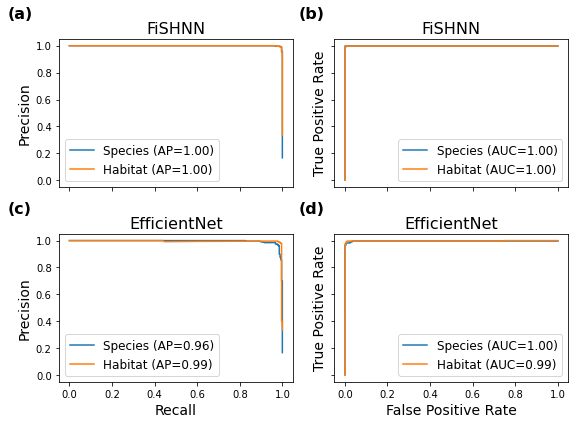

In [9]:
# Precision-Recall and ROC curves
# FiSHNN Precision-Recall
precision_f_spe, recall_f_spe, _ = precision_recall_curve(species_targets_onehot.ravel(), fishnn_species_probs.ravel())
precision_f_hab, recall_f_hab, _ = precision_recall_curve(habitat_targets_onehot.ravel(), fishnn_habitat_probs.ravel())
average_precision_f_spe = average_precision_score(species_targets_onehot, fishnn_species_probs)
average_precision_f_hab = average_precision_score(habitat_targets_onehot, fishnn_habitat_probs)

# Single-task Precision-Recall
precision_s_spe, recall_s_spe, _ = precision_recall_curve(species_targets_onehot.ravel(), species_probs.ravel())
precision_s_hab, recall_s_hab, _ = precision_recall_curve(habitat_targets_onehot.ravel(), habitat_probs.ravel())
average_precision_s_spe = average_precision_score(species_targets_onehot, species_probs)
average_precision_s_hab = average_precision_score(habitat_targets_onehot, habitat_probs)

# FiSHNN ROC
fpr_f_spe, tpr_f_spe, _ = roc_curve(species_targets_onehot.ravel(), fishnn_species_probs.ravel())
auc_f_spe = roc_auc_score(species_targets_onehot, fishnn_species_probs)
fpr_f_hab, tpr_f_hab, _ = roc_curve(habitat_targets_onehot.ravel(), fishnn_habitat_probs.ravel())
auc_f_hab = roc_auc_score(habitat_targets_onehot, fishnn_habitat_probs)

# Single-task ROC
fpr_s_spe, tpr_s_spe, _ = roc_curve(species_targets_onehot.ravel(), species_probs.ravel())
auc_s_spe = roc_auc_score(species_targets_onehot, species_probs)
fpr_s_hab, tpr_s_hab, _ = roc_curve(habitat_targets_onehot.ravel(), habitat_probs.ravel())
auc_s_hab = roc_auc_score(habitat_targets_onehot, habitat_probs)

# Plot Evaluation Curves
# Use sharex='col' to automatically hide redundant tick labels in the first row
fig, ax = plt.subplots(2, 2, figsize=(8, 6), sharey='row', sharex='col')

# Row 1: FiSHNN
ax[0, 0].plot(recall_f_spe, precision_f_spe, label=f'Species (AP={average_precision_f_spe:.2f})')
ax[0, 0].plot(recall_f_hab, precision_f_hab, label=f'Habitat (AP={average_precision_f_hab:.2f})')
ax[0, 0].set_ylabel('Precision', fontsize=14)
ax[0, 0].set_title('FiSHNN', fontsize=16)
ax[0, 0].text(-0.22, 1.22, '(a)', transform=ax[0, 0].transAxes, ha='left', va='top', fontsize=16, fontweight='bold')
ax[0, 0].legend(fontsize=12)

ax[0, 1].plot(fpr_f_spe, tpr_f_spe, label=f'Species (AUC={auc_f_spe:.2f})')
ax[0, 1].plot(fpr_f_hab, tpr_f_hab, label=f'Habitat (AUC={auc_f_hab:.2f})')
ax[0, 1].set_ylabel('True Positive Rate', fontsize=14)
ax[0, 1].set_title('FiSHNN', fontsize=16)
ax[0, 1].text(-0.15, 1.22, '(b)', transform=ax[0, 1].transAxes, ha='left', va='top', fontsize=16, fontweight='bold')
ax[0, 1].legend(fontsize=12)

# Row 2: Single-task (EfficientNet)
ax[1, 0].plot(recall_s_spe, precision_s_spe, label=f'Species (AP={average_precision_s_spe:.2f})')
ax[1, 0].plot(recall_s_hab, precision_s_hab, label=f'Habitat (AP={average_precision_s_hab:.2f})')
ax[1, 0].set_xlabel('Recall', fontsize=14)
ax[1, 0].set_ylabel('Precision', fontsize=14)
ax[1, 0].set_title('EfficientNet', fontsize=16)
ax[1, 0].text(-0.22, 1.22, '(c)', transform=ax[1, 0].transAxes, ha='left', va='top', fontsize=16, fontweight='bold')
ax[1, 0].legend(fontsize=12)

ax[1, 1].plot(fpr_s_spe, tpr_s_spe, label=f'Species (AUC={auc_s_spe:.2f})')
ax[1, 1].plot(fpr_s_hab, tpr_s_hab, label=f'Habitat (AUC={auc_s_hab:.2f})')
ax[1, 1].set_xlabel('False Positive Rate', fontsize=14)
ax[1, 1].set_ylabel('True Positive Rate', fontsize=14)
ax[1, 1].set_title('EfficientNet', fontsize=16)
ax[1, 1].text(-0.15, 1.22, '(d)', transform=ax[1, 1].transAxes, ha='left', va='top', fontsize=16, fontweight='bold')
ax[1, 1].legend(fontsize=12)

plt.tight_layout()
fig.savefig('./Figs/Figure_S3_evaluation.pdf')
fig.savefig('./Figs/Figure_S3_evaluation.png', dpi=600, bbox_inches='tight')